# Setup
In colab:

Go to "Runtime" -> "Change runtime type" -> Select "T4 GPU"
Install TerraTorch

In [1]:
%%time
!pip install terratorch==1.0.1 gdown
# Install leafmap
!pip install leafmap
!wget https://raw.githubusercontent.com/eugenegene/terramind/colab_compat/notebooks/plotting_utils.py

--2025-08-04 17:02:49--  https://raw.githubusercontent.com/eugenegene/terramind/colab_compat/notebooks/plotting_utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9503 (9.3K) [text/plain]
Saving to: ‘plotting_utils.py.1’

plotting_utils.py.1 100%[===================>]   9.28K  --.-KB/s    in 0s      

2025-08-04 17:02:49 (109 MB/s) - ‘plotting_utils.py.1’ saved [9503/9503]

CPU times: user 4.54 s, sys: 1.82 s, total: 6.35 s
Wall time: 22.1 s


# Large-tile generation

TerraMind was pre-trained on small patches of 224x224 pixels. Passing larger inputs to the model works as long as it is a multiple of 16x16 pixel. However, this is outside the training scope and can lead to worse generation results or OOM errors.
This example performs generation of a larger tile using the `tiled_inference` function provided by TerraTorch.  

In [2]:
%%time
import os
import torch
import rioxarray as rxr
import matplotlib.pyplot as plt

from plotting_utils import (
    plot_s2, plot_modality,
    s2_to_rgb, s1_to_rgb, dem_to_rgb, ndvi_to_rgb, lulc_to_rgb
)
import leafmap
from terratorch.registry import FULL_MODEL_REGISTRY
from terratorch.tasks.tiled_inference import tiled_inference
from huggingface_hub import hf_hub_download



# Select device
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

device

CPU times: user 18.4 s, sys: 6.44 s, total: 24.9 s
Wall time: 39.5 s


'cuda'

In [3]:
%%time
# Download Santiago large-scale example from Hugging Face (2000x2000 pixel)
if not os.path.isfile('../examples/S2L2A/Santiago.tif'):
    hf_hub_download(repo_id='ibm-esa-geospatial/Examples',
                    filename='S2L2A/Santiago.tif',
                    repo_type='dataset', local_dir='../examples/')

CPU times: user 23 µs, sys: 8 µs, total: 31 µs
Wall time: 34.6 µs


In [4]:
%%time
# Download Singpore large-scale example from Hugging Face (2000x2000 pixel)
if not os.path.isfile('../examples/S2L2A/Singapore_2025-01-09.tif'):
    hf_hub_download(repo_id='ibm-esa-geospatial/Examples',
                    filename='S2L2A/Singapore_2025-01-09.tif',
                    repo_type='dataset', local_dir='../examples/')

CPU times: user 22 µs, sys: 8 µs, total: 30 µs
Wall time: 33.4 µs


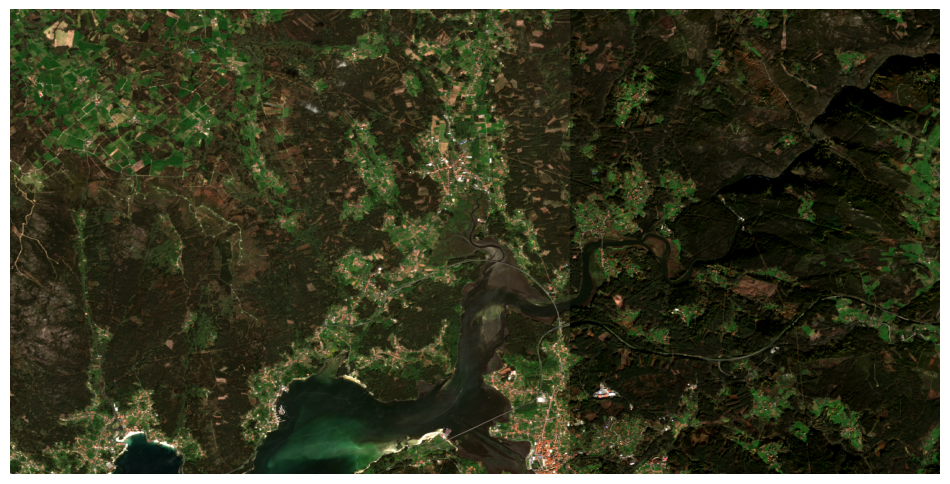

CPU times: user 649 ms, sys: 245 ms, total: 894 ms
Wall time: 1.41 s


In [5]:
%%time
# Load Singapore tile
# data = rxr.open_rasterio('../examples/S2L2A/Singapore_2025-01-09.tif').values

# Load Santiago tile (alternative input)
data = rxr.open_rasterio('../examples/S2L2A/Santiago.tif').values

# Optionally reduce image size to speed up inference
data = data[:, 500:1500]

# Display the input
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
plot_s2(data, ax=ax)
plt.show()

In [6]:
%%time
# Build input tensor and add batch dimension
input = torch.tensor(data, dtype=torch.float, device=device).unsqueeze(0)

# Build model
model = FULL_MODEL_REGISTRY.build(
    'terramind_v1_base_generate',
    modalities=['S2L2A'],
    output_modalities=['S1GRD', 'DEM', 'LULC', 'NDVI'],
    pretrained=True,
    standardize=True,
    timesteps=10,  # Number of diffusion steps
)

model = model.to(device)

CPU times: user 21.8 s, sys: 6.51 s, total: 28.4 s
Wall time: 51.4 s


# Run inference

`tiled_inference` can be used with any model as long as the output of the passed `forward` function returns a tensor. We therefore wrap the model and stack the generated modalities.

In [7]:
%%time
from terratorch.tasks.tiled_inference import TiledInferenceParameters

# Define model forward for tiled inference
def model_forward(x, **kwargs):
    # Run chained generation for all output modalities
    generated = model(x)

    # TerraTorch tiled inference expects a tensor output from model forward.
    # We concatenate all generations along channel dimension.
    out = torch.concat([
        generated['S1GRD'],
        generated['DEM'],
        generated['LULC'],
        generated['NDVI']
    ], dim=1)

    return out

# Define the parameters properly
inference_params = TiledInferenceParameters(
    h_crop=256,
    w_crop=256,
    h_stride=128,
    w_stride=128
)

pred = tiled_inference(model_forward, input, crop=256, stride=128,
                       batch_size=16, out_channels=14,
                       inference_parameters=inference_params, verbose=True)
pred = pred.squeeze(0)  # Remove batch dim

# Split up the stacked bands into each modality
generated = {
    'S1GRD': pred[0:2],
    'DEM': pred[2],
    'LULC': pred[3:13].argmax(0),  # Get class predictions from logits
    'NDVI': pred[-1],
}

CPU times: user 1min 41s, sys: 539 ms, total: 1min 41s
Wall time: 1min 45s


# Analyze the generations

Let's have a look at the generations. You can notice that all modalities capture the general features quite well but are often wrongly scaled. While S1 and NDVI values are closer to the mean values than the ground trough, DEM generations clearly shows the smaller patches of the tiled inference. The model fails to estimate the general elevation of each single patch. Because of the tiled inference, some generations can look a bit patchy, e.g., S1 below clouds as the model estimates the shoreline.

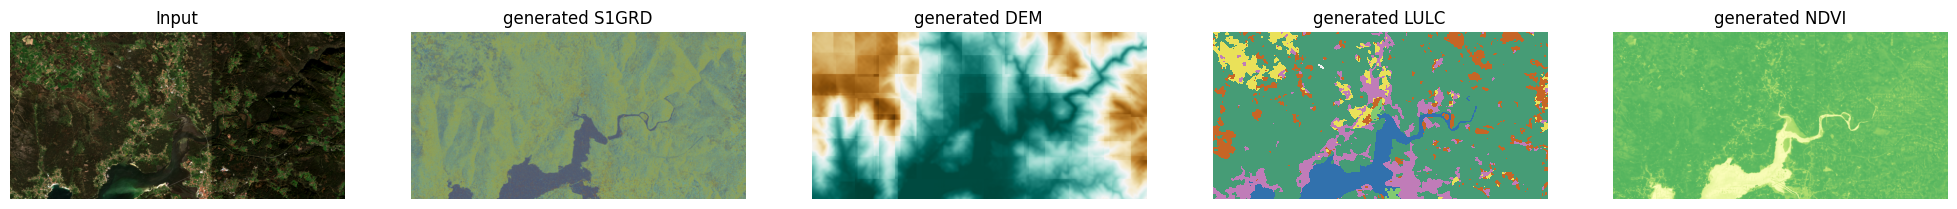

CPU times: user 1.26 s, sys: 8.46 ms, total: 1.27 s
Wall time: 1.27 s


In [8]:
%%time
# Plot generations
n_plots = len(generated) + 1
fig, ax = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))

plot_s2(input, ax=ax[0])
ax[0].set_title('Input')

for i, (mod, value) in enumerate(generated.items()):
    plot_modality(mod, value, ax=ax[i + 1])

    ax[i+1].set_title('generated ' + mod)

plt.show()

# Compare generations in split view

We use leafmap for the interactive visualisation of a generation.


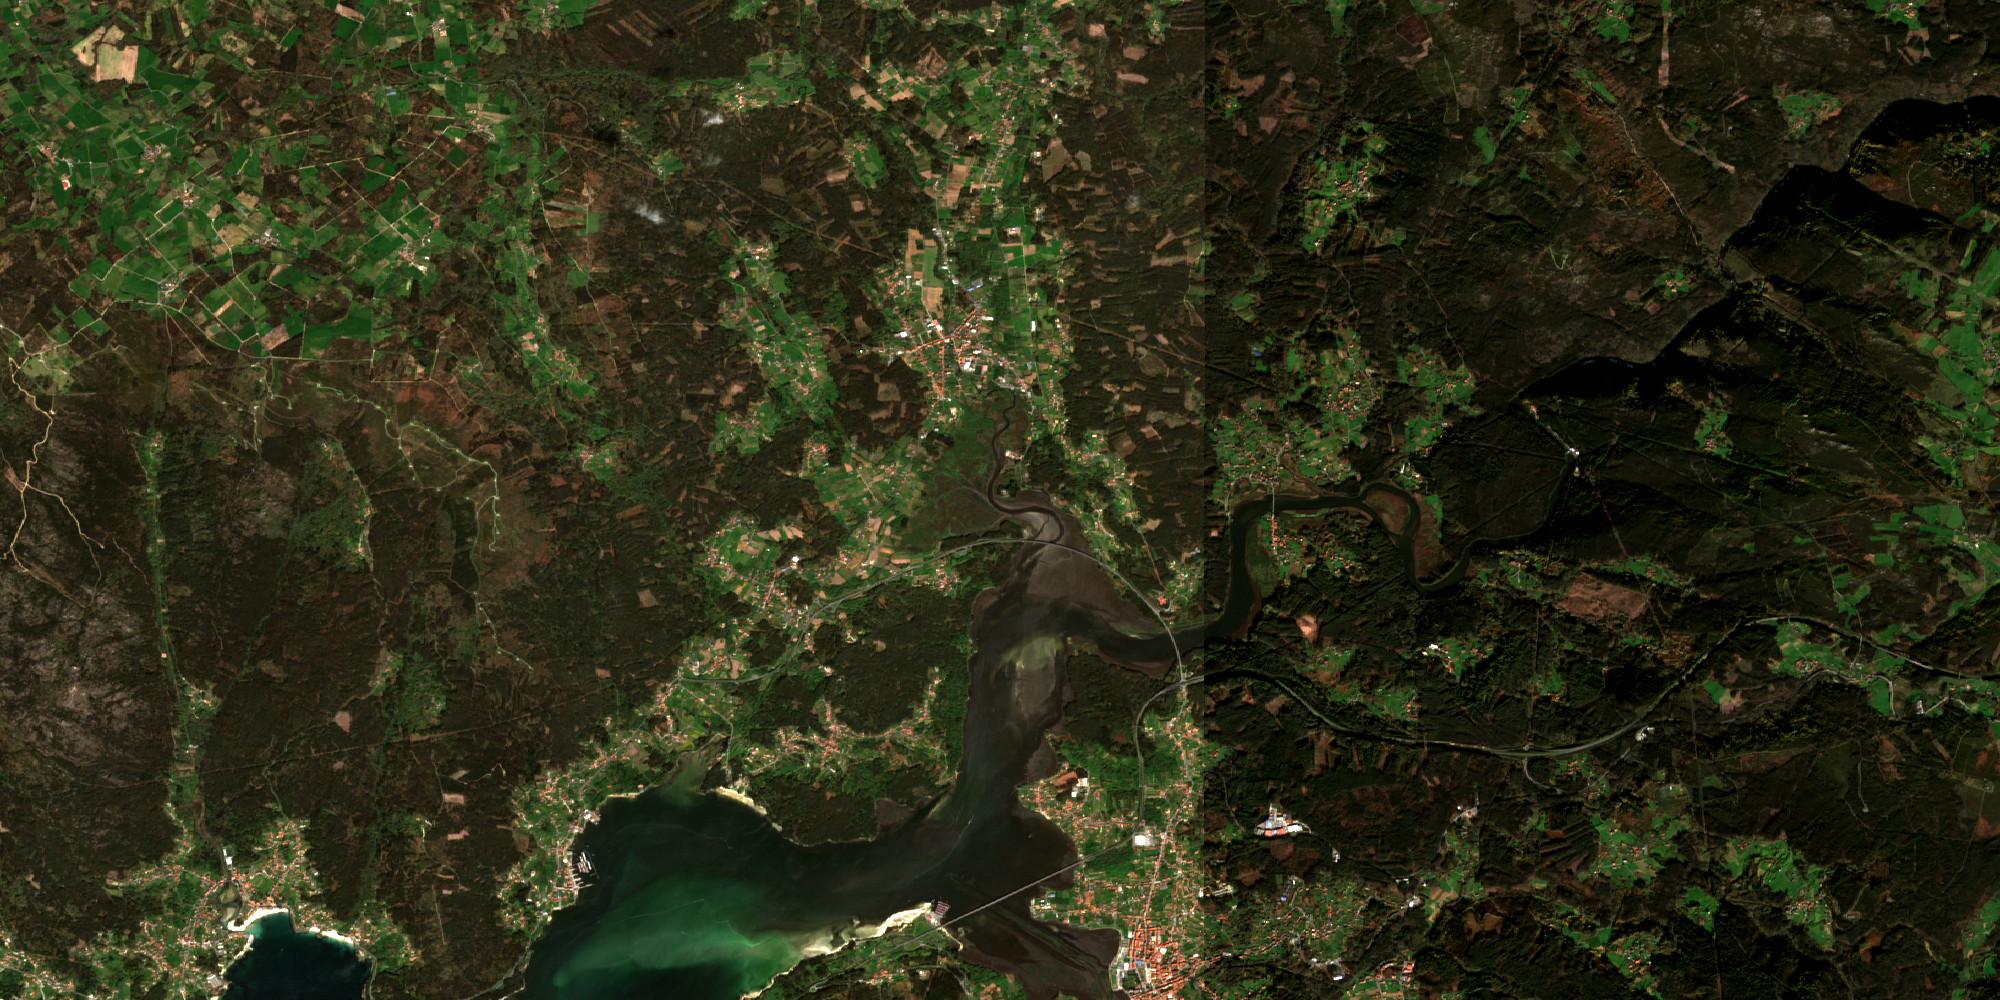
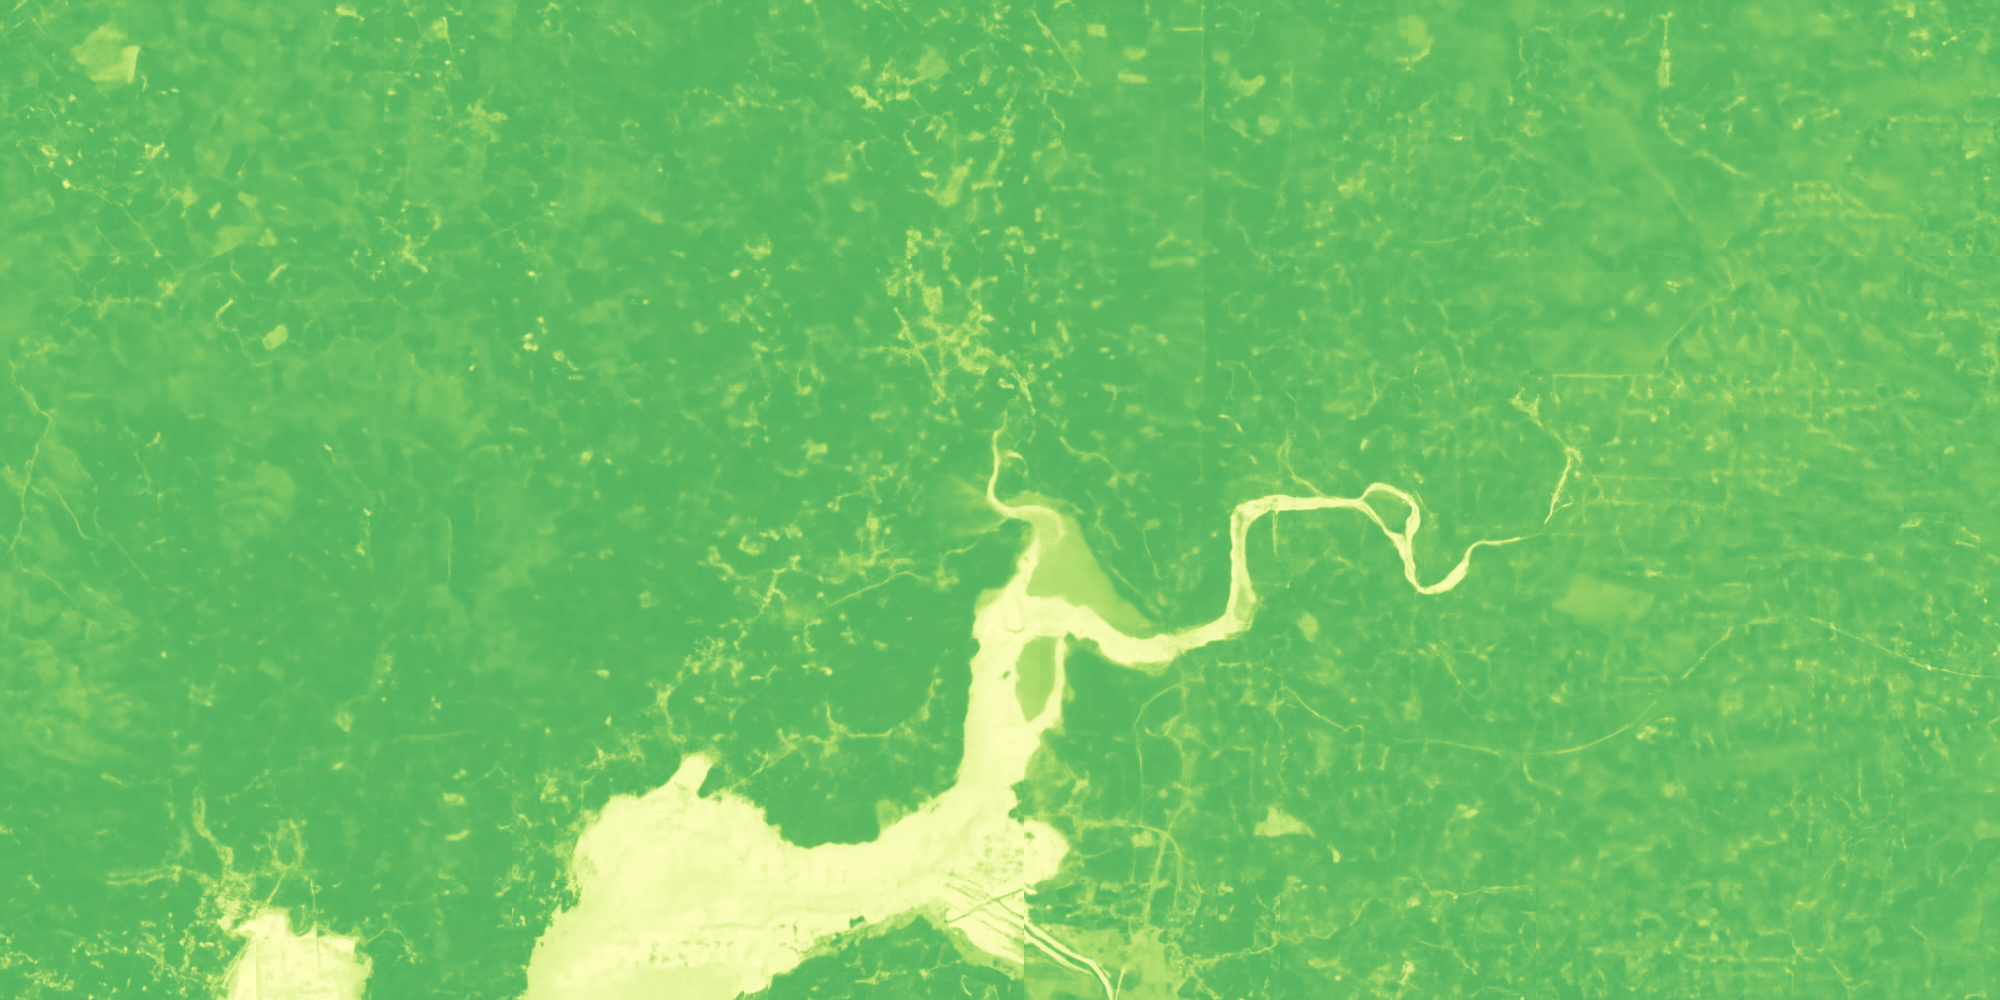

In [18]:
# Plot comparison using leafmap
leafmap.image_comparison(
    s2_to_rgb(input.cpu()),
    # s1_to_rgb(generated['S1GRD'].cpu()),
    # dem_to_rgb(generated['DEM'].cpu()),
    # ndvi_to_rgb(generated['NDVI'].cpu()),
    lulc_to_rgb(generated['LULC'].cpu()),
    label1="S-2 L2A",
    label2="Generated data",
    starting_position=50,
    out_html="image_comparison.html",
)